**Continuous UAV RL Path Planning**

RL algorithms included:
- DQN
- Double DQN
- Dueling DQN
- IDDQN: Double + dueling + adaptive epsilon + soft target updates + optional expert warm-start

In [24]:
import heapq
import math
import random
import time
from collections import deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.patches import Rectangle

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [25]:
@dataclass
class UAVConfig:
    world_size: float = 40.0 # Tuneable
    start: tuple = (4.0, 3.0)
    target: tuple = (35.0, 36.0)
    step_size: float = 0.75
    target_radius: float = 0.9
    safety_margin: float = 0.25
    max_steps: int = 180
    episodes: int = 1000
    gamma: float = 0.92
    lr: float = 0.002
    batch_size: int = 64
    memory_size: int = 30000
    target_update: int = 10
    soft_tau: float = 0.02
    eps_start: float = 0.90
    eps_end: float = 0.02
    eps_decay: float = 500.0
    target_reward: float = 600.0
    obstacle_penalty: float = -350.0
    no_fly_penalty: float = -450.0
    boundary_penalty: float = -350.0
    step_penalty: float = -0.08
    distance_scale: float = -0.015
    progress_scale: float = 4.0
    grad_clip: float = 10.0

cfg = UAVConfig()
CHECKPOINT_DIR = Path("continuous_uav_rl_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
METRICS_CSV = Path("continuous_uav_rl_metrics.csv")
PATH_PLOT = Path("continuous_uav_rl_paths.png")
REWARD_CSV = Path("continuous_uav_rl_episode_rewards.csv")
REWARD_PLOT = Path("continuous_uav_rl_reward_curves.png")
cfg

UAVConfig(world_size=40.0, start=(4.0, 3.0), target=(35.0, 36.0), step_size=0.75, target_radius=0.9, safety_margin=0.25, max_steps=180, episodes=1000, gamma=0.92, lr=0.002, batch_size=64, memory_size=30000, target_update=10, soft_tau=0.02, eps_start=0.9, eps_end=0.02, eps_decay=500.0, target_reward=600.0, obstacle_penalty=-350.0, no_fly_penalty=-450.0, boundary_penalty=-350.0, step_penalty=-0.08, distance_scale=-0.015, progress_scale=4.0, grad_clip=10.0)

In [ ]:
# Obstacles, No fly zones
OBSTACLE_RECTS = [
    (2, 16, 8, 2),
    (9, 25, 7, 5),
    (10, 9, 5, 3),
    (13, 17, 8, 4),
    (17, 3, 5, 7),
    (20, 24, 7, 4),
    (25, 29, 11, 6),
    (26, 9, 9, 3),
    (29, 15, 8, 5),
]

NO_FLY_RECTS = [
    (6, 31, 7, 3),
    (18, 12, 4, 4),
    (23, 21, 5, 3),
    (31, 4, 5, 5),
]

ACTIONS_8 = np.array([
    [0, 1], [0, -1], [-1, 0], [1, 0],
    [1, 1], [1, -1], [-1, 1], [-1, -1],
], dtype=np.float32)
ACTIONS_8 = ACTIONS_8 / np.linalg.norm(ACTIONS_8, axis=1, keepdims=True)

def point_in_rect(point, rect, margin=0.0):
    x, y = point
    rx, ry, rw, rh = rect
    return (rx - margin) <= x <= (rx + rw + margin) and (ry - margin) <= y <= (ry + rh + margin)


def point_in_any_rect(point, rects, margin=0.0):
    return any(point_in_rect(point, rect, margin) for rect in rects)


def rect_distance(point, rect):
    x, y = point
    rx, ry, rw, rh = rect
    cx = min(max(x, rx), rx + rw)
    cy = min(max(y, ry), ry + rh)
    return math.hypot(x - cx, y - cy)


def nearest_rect_distance(point, rects):
    return min(rect_distance(point, rect) for rect in rects) if rects else float("inf")


In [27]:
class ContinuousUAVEnv:
    def __init__(self, config, obstacles, no_fly_zones):
        self.cfg = config
        self.obstacles = list(obstacles)
        self.no_fly_zones = list(no_fly_zones)
        self.actions = ACTIONS_8 * config.step_size
        self.state_size = 5 # [x, y, TD, OD, No Fly Zone]
        self.action_size = len(self.actions)
        self.start = np.array(config.start, dtype=np.float32)
        self.target = np.array(config.target, dtype=np.float32)
        self.reset()

    def reset(self):
        self.pos = self.start.copy()
        self.steps = 0
        self.done = False
        self.path = [tuple(self.pos)]
        return self._state()

    def target_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        return float(np.linalg.norm(p - self.target))

    def obstacle_distance(self, pos=None):
        p = self.pos if pos is None else tuple(pos)
        return float(nearest_rect_distance(tuple(p), self.obstacles))

    def no_fly_distance(self, pos=None):
        p = self.pos if pos is None else tuple(pos)
        return float(nearest_rect_distance(tuple(p), self.no_fly_zones))

    def _state(self):
        max_dist = math.sqrt(2) * self.cfg.world_size
        return np.array([
            self.pos[0] / self.cfg.world_size,
            self.pos[1] / self.cfg.world_size,
            self.target_distance() / max_dist,
            min(self.obstacle_distance(), max_dist) / max_dist,
            min(self.no_fly_distance(), max_dist) / max_dist,
        ], dtype=np.float32)

    def step(self, action_idx):
        if self.done:
            return self._state(), 0.0, True, {}

        previous_td = self.target_distance()
        proposed = self.pos + self.actions[action_idx]
        self.steps += 1
        self.pos = proposed.astype(np.float32)
        self.path.append(tuple(self.pos))

        out = bool(self.pos[0] < 0 or self.pos[0] > self.cfg.world_size or self.pos[1] < 0 or self.pos[1] > self.cfg.world_size)
        in_obstacle = point_in_any_rect(tuple(self.pos), self.obstacles, margin=self.cfg.safety_margin)
        in_no_fly = point_in_any_rect(tuple(self.pos), self.no_fly_zones, margin=self.cfg.safety_margin)
        td = self.target_distance()
        od = self.obstacle_distance()
        nd = self.no_fly_distance()
        reached = td <= self.cfg.target_radius

        reward = self.cfg.step_penalty + self.cfg.distance_scale * td + self.cfg.progress_scale * (previous_td - td)
        if reached:
            reward += self.cfg.target_reward
        if in_obstacle:
            reward += self.cfg.obstacle_penalty
        if in_no_fly:
            reward += self.cfg.no_fly_penalty
        if out:
            reward += self.cfg.boundary_penalty

        self.done = bool(reached or in_obstacle or in_no_fly or out or self.steps >= self.cfg.max_steps)
        info = {
            "target_distance": td,
            "obstacle_distance": od,
            "no_fly_distance": nd,
            "reached": reached,
            "collision": in_obstacle,
            "no_fly_violation": in_no_fly,
            "out_of_bounds": out,
        }
        return self._state(), float(reward), self.done, info


env = ContinuousUAVEnv(cfg, OBSTACLE_RECTS, NO_FLY_RECTS)
env.reset(), env.state_size, env.action_size

(array([0.1       , 0.075     , 0.8003905 , 0.15      , 0.29421505],
       dtype=float32),
 5,
 8)

In [28]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, action_size),
        )

    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
        )
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, action_size))

    def forward(self, x):
        z = self.feature(x)
        value = self.value(z)
        advantage = self.advantage(z)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


class ReplayBuffer:
    def __init__(self, capacity):
        self.data = deque(maxlen=capacity)

    def __len__(self):
        return len(self.data)

    def push(self, state, action, reward, next_state, done):
        self.data.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.data, batch_size))
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )


class UAVRLAgent:
    def __init__(self, state_size, action_size, config, algorithm):
        self.cfg = config
        self.algorithm = algorithm
        self.action_size = action_size
        net_cls = DuelingQNetwork if algorithm in {"Dueling DQN", "IDDQN"} else QNetwork
        self.current_net = net_cls(state_size, action_size).to(DEVICE)
        self.target_net = net_cls(state_size, action_size).to(DEVICE)
        self.target_net.load_state_dict(self.current_net.state_dict())
        self.target_net.eval()
        self.memory = ReplayBuffer(config.memory_size)
        self.optimizer = optim.Adam(self.current_net.parameters(), lr=config.lr)
        self.loss_fn = nn.MSELoss()

    def epsilon(self, episode):
        if self.algorithm == "IDDQN":
            return self.cfg.eps_end + (self.cfg.eps_start - self.cfg.eps_end) / (1.0 + math.exp(episode / self.cfg.eps_decay))
        return max(self.cfg.eps_end, self.cfg.eps_start * (0.995 ** episode))

    def act(self, state, episode=10_000, greedy=False):
        eps = 0.0 if greedy else self.epsilon(episode)
        if random.random() < eps:
            return random.randrange(self.action_size)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.current_net(s).argmax(dim=1).item())

    def learn(self):
        if len(self.memory) < self.cfg.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(self.cfg.batch_size)
        q_values = self.current_net(states).gather(1, actions)
        with torch.no_grad():
            if self.algorithm in {"Double DQN", "IDDQN"}:
                next_actions = self.current_net(next_states).argmax(dim=1, keepdim=True)
                next_q = self.target_net(next_states).gather(1, next_actions)
            else:
                next_q = self.target_net(next_states).max(dim=1, keepdim=True).values
            target = rewards + self.cfg.gamma * next_q * (1.0 - dones)
        loss = self.loss_fn(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.current_net.parameters(), self.cfg.grad_clip)
        self.optimizer.step()
        return float(loss.item())

    def update_target(self, soft=False):
        if soft:
            tau = self.cfg.soft_tau
            for target_param, current_param in zip(self.target_net.parameters(), self.current_net.parameters()):
                target_param.data.copy_(tau * current_param.data + (1.0 - tau) * target_param.data)
        else:
            self.target_net.load_state_dict(self.current_net.state_dict())

In [29]:
# Continuous expert route used only for optional warm-start/testing stability.
# It deliberately avoids black obstacles and red no-fly zones.
EXPERT_WAYPOINTS = np.array([
    cfg.start,
    (5.0, 7.0),
    (8.0, 10.0),
    (10.0, 15.0),
    (14.0, 20.0),
    (17.0, 23.0),
    (21.0, 28.0),
    (28.0, 32.0),
    cfg.target,
], dtype=np.float32)


def action_toward(env, current, target):
    direction = np.array(target, dtype=np.float32) - np.array(current, dtype=np.float32)
    if np.linalg.norm(direction) < 1e-9:
        return 0
    direction = direction / np.linalg.norm(direction)
    dots = env.actions @ direction
    return int(np.argmax(dots))


def expert_transitions(env, waypoints):
    transitions = []
    state = env.reset()
    waypoint_idx = 1
    while waypoint_idx < len(waypoints) and len(transitions) < env.cfg.max_steps:
        if np.linalg.norm(env.pos - waypoints[waypoint_idx]) <= env.cfg.step_size:
            waypoint_idx += 1
            continue
        action = action_toward(env, env.pos, waypoints[waypoint_idx])
        next_state, reward, done, _ = env.step(action)
        transitions.append((state, action, reward, next_state, done))
        state = next_state
        if done:
            break
    return transitions


def prefill_replay(env, agent, repeats=40):
    transitions = expert_transitions(env, EXPERT_WAYPOINTS)
    for _ in range(repeats):
        for transition in transitions:
            agent.memory.push(*transition)


def behavior_clone(env, agent, epochs=250):
    transitions = expert_transitions(env, EXPERT_WAYPOINTS)
    if not transitions:
        return None
    states = torch.tensor(np.array([t[0] for t in transitions]), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor([t[1] for t in transitions], dtype=torch.long, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        logits = agent.current_net(states)
        loss = loss_fn(logits, actions)
        agent.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.current_net.parameters(), agent.cfg.grad_clip)
        agent.optimizer.step()
    agent.target_net.load_state_dict(agent.current_net.state_dict())
    return float(loss.item())

len(expert_transitions(env, EXPERT_WAYPOINTS))

25

In [30]:
def train_agent(env, agent, episodes=None, verbose_every=100):
    episodes = episodes or env.cfg.episodes
    history = {"reward": [], "steps": [], "success": [], "loss": []}
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0.0
        losses = []
        final_info = {}
        for _ in range(env.cfg.max_steps):
            action = agent.act(state, episode)
            next_state, reward, done, info = env.step(action)
            agent.memory.push(state, action, reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                losses.append(loss)
            if agent.algorithm == "IDDQN":
                agent.update_target(soft=True)
            state = next_state
            total_reward += reward
            final_info = info
            if done:
                break
        if agent.algorithm != "IDDQN" and episode % env.cfg.target_update == 0:
            agent.update_target(soft=False)
        history["reward"].append(total_reward)
        history["steps"].append(env.steps)
        history["success"].append(bool(final_info.get("reached", False)))
        history["loss"].append(float(np.mean(losses)) if losses else np.nan)
        if verbose_every and (episode + 1) % verbose_every == 0:
            print(f"{agent.algorithm:12s} | episode {episode + 1:4d}/{episodes} | reward {total_reward:8.2f} | recent success {np.mean(history['success'][-verbose_every:]):.2f}")
    return history


def greedy_rollout(env, agent):
    start_time = time.perf_counter()
    state = env.reset()
    total_reward = 0.0
    final_info = {}
    for _ in range(env.cfg.max_steps):
        action = agent.act(state, greedy=True)
        state, reward, done, info = env.step(action)
        total_reward += reward
        final_info = info
        if done:
            break
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return list(env.path), total_reward, final_info, elapsed_ms

In [31]:
# Main training/comparison cell.
# Reduce cfg.episodes for quick tests; increase and repeat seeds for publication-grade results.
RUN_TRAINING = True
USE_EXPERT_WARMSTART = True
ALGORITHMS = ["DQN", "Double DQN", "Dueling DQN", "IDDQN"]

agents = {}
histories = {}
paths = {}
rollout_info = {}
rollout_rewards = {}
inference_times = {}

for algorithm in ALGORITHMS:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    local_env = ContinuousUAVEnv(cfg, OBSTACLE_RECTS, NO_FLY_RECTS)
    agent = UAVRLAgent(local_env.state_size, local_env.action_size, cfg, algorithm)
    checkpoint_path = CHECKPOINT_DIR / f"{algorithm.replace(' ', '_').lower()}_continuous_uav.pth"

    if RUN_TRAINING:
        if USE_EXPERT_WARMSTART:
            prefill_replay(local_env, agent, repeats=40)
        if algorithm == "IDDQN":
            behavior_clone(local_env, agent, epochs=300)
        histories[algorithm] = train_agent(local_env, agent, episodes=cfg.episodes, verbose_every=100)
        if algorithm == "IDDQN":
            behavior_clone(local_env, agent, epochs=300)
        torch.save(agent.current_net.state_dict(), checkpoint_path)
    elif checkpoint_path.exists():
        agent.current_net.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        agent.target_net.load_state_dict(agent.current_net.state_dict())
    else:
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    path, reward, info, elapsed_ms = greedy_rollout(local_env, agent)
    agents[algorithm] = agent
    paths[algorithm] = path
    rollout_info[algorithm] = info
    rollout_rewards[algorithm] = reward
    inference_times[algorithm] = elapsed_ms

{name: {"steps": len(path) - 1, "reached": rollout_info[name].get("reached", False)} for name, path in paths.items()}

DQN          | episode  100/1000 | reward  -360.24 | recent success 0.00
DQN          | episode  200/1000 | reward  -332.31 | recent success 0.00
DQN          | episode  300/1000 | reward  -330.51 | recent success 0.00
DQN          | episode  400/1000 | reward  -301.73 | recent success 0.00
DQN          | episode  500/1000 | reward  -267.24 | recent success 0.00
DQN          | episode  600/1000 | reward  -318.73 | recent success 0.00
DQN          | episode  700/1000 | reward  -371.01 | recent success 0.03
DQN          | episode  800/1000 | reward  -284.84 | recent success 0.00
DQN          | episode  900/1000 | reward  -322.67 | recent success 0.01
DQN          | episode 1000/1000 | reward  -372.64 | recent success 0.15
Double DQN   | episode  100/1000 | reward  -336.95 | recent success 0.00
Double DQN   | episode  200/1000 | reward  -348.99 | recent success 0.00
Double DQN   | episode  300/1000 | reward  -299.65 | recent success 0.00
Double DQN   | episode  400/1000 | reward   -34.75 

{'DQN': {'steps': 180, 'reached': False},
 'Double DQN': {'steps': 72, 'reached': True},
 'Dueling DQN': {'steps': 75, 'reached': True},
 'IDDQN': {'steps': 25, 'reached': False}}

In [35]:
def path_length(path):
    return float(sum(math.hypot(b[0] - a[0], b[1] - a[1]) for a, b in zip(path[:-1], path[1:]))) if len(path) > 1 else 0.0


def min_clearance(path, rects):
    if not path:
        return 0.0
    return float(min(nearest_rect_distance(point, rects) for point in path))


def count_corners(path, angle_tol_deg=10):
    if len(path) < 3:
        return 0
    corners = 0
    for a, b, c in zip(path[:-2], path[1:-1], path[2:]):
        v1 = np.array(b) - np.array(a)
        v2 = np.array(c) - np.array(b)
        if np.linalg.norm(v1) < 1e-9 or np.linalg.norm(v2) < 1e-9:
            continue
        cosang = np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1, 1)
        angle = math.degrees(math.acos(cosang))
        if angle > angle_tol_deg:
            corners += 1
    return corners

rows = []
for algorithm in ALGORITHMS:
    info = rollout_info[algorithm]
    path = paths[algorithm]
    rows.append({
        "algorithm": algorithm,
        "reward": round(rollout_rewards[algorithm], 4),
        "steps": len(path) - 1,
        "target_distance": round(float(info.get("target_distance", math.inf)), 4),
        "obstacle_distance": round(min_clearance(path, OBSTACLE_RECTS), 4),
        "no_fly_distance": round(min_clearance(path, NO_FLY_RECTS), 4),
        "path_length": round(path_length(path), 4),
        "corners": count_corners(path),
        "inference_time_ms": round(inference_times[algorithm], 4),
        "reached": bool(info.get("reached", False)),
        "collision": bool(info.get("collision", False)),
        "no_fly_violation": bool(info.get("no_fly_violation", False)),
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(METRICS_CSV, index=False)
metrics_df

,algorithm,reward,steps,target_distance,obstacle_distance,no_fly_distance,path_length,corners,inference_time_ms,reached,collision,no_fly_violation
0,DQN,6.6596,180,22.9478,0.4844,4.9844,135.00,155,35.8508,False,False,False
1,Double DQN,747.9212,72,0.5801,0.5999,4.8022,54.00,19,10.9993,True,False,False
2,Dueling DQN,749.4956,75,0.2657,0.3704,4.7380,56.25,26,23.8834,True,False,False
3,IDDQN,-298.2605,25,28.4034,0.0000,5.3765,18.75,11,6.3501,False,True,False


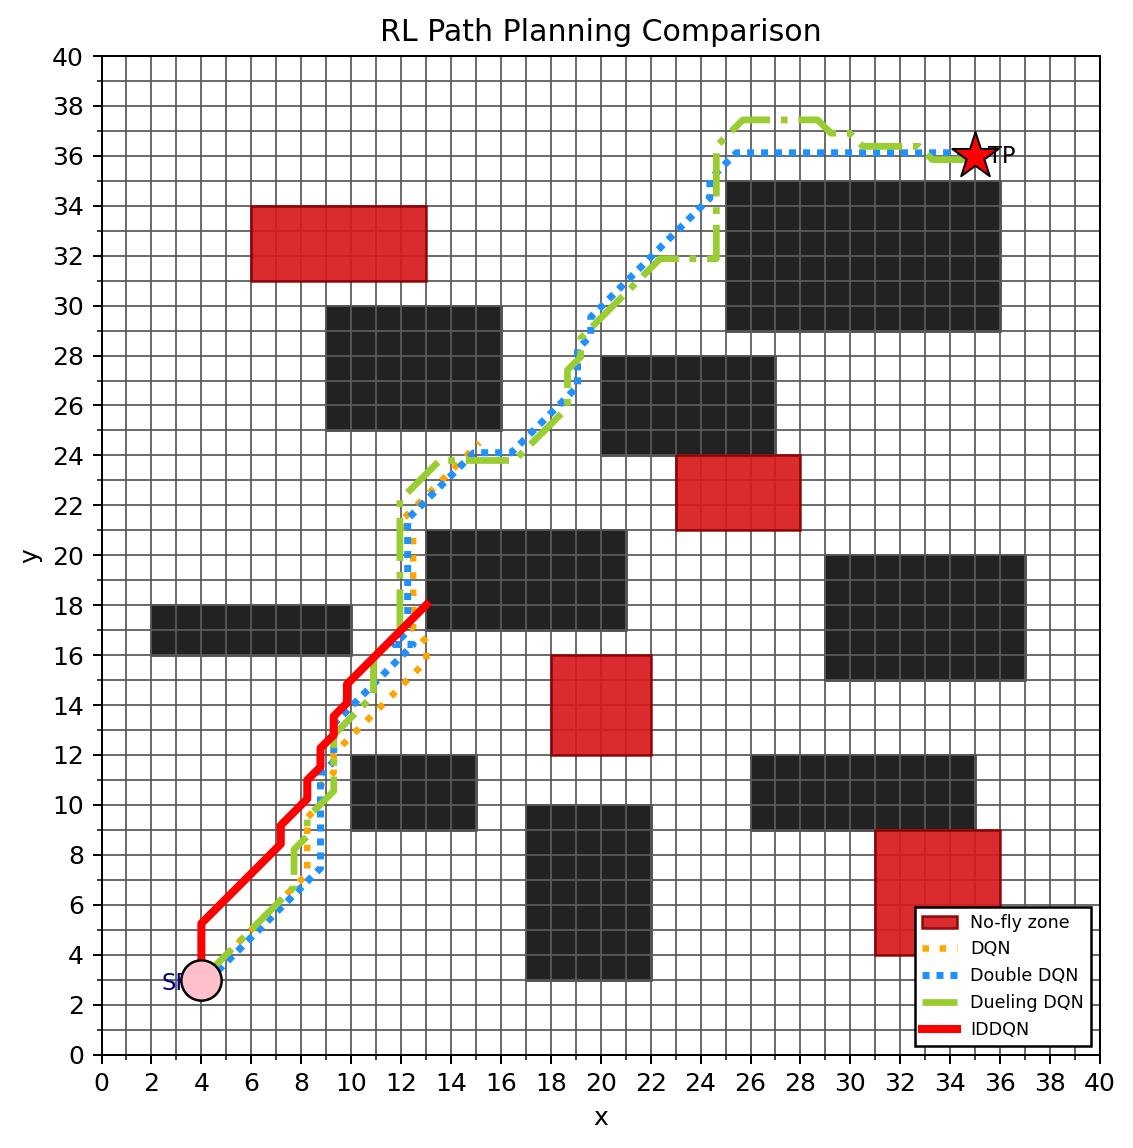

In [36]:
STYLE = {
    "DQN": {"color": "orange", "linestyle": ":", "linewidth": 2.6},
    "Double DQN": {"color": "dodgerblue", "linestyle": (0, (1, 1)), "linewidth": 2.8},
    "Dueling DQN": {"color": "yellowgreen", "linestyle": "-.", "linewidth": 2.7},
    "IDDQN": {"color": "red", "linestyle": "-", "linewidth": 3.2},
}


def plot_continuous_uav_paths(paths, save_path=PATH_PLOT):
    fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=180)
    ax.set_xlim(0, cfg.world_size)
    ax.set_ylim(0, cfg.world_size)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(0, cfg.world_size + 1, 2))
    ax.set_yticks(np.arange(0, cfg.world_size + 1, 2))
    ax.set_xticks(np.arange(0, cfg.world_size + 1, 1), minor=True)
    ax.set_yticks(np.arange(0, cfg.world_size + 1, 1), minor=True)
    ax.grid(which="both", color="#5a5a5a", linewidth=0.7)

    # Black obstacle blocks.
    for rect in OBSTACLE_RECTS:
        ax.add_patch(
            Rectangle(
                (rect[0], rect[1]), rect[2], rect[3],
                facecolor="#222222", edgecolor="#222222", zorder=1,
            )
        )

    # Red no-fly zones.
    for idx, rect in enumerate(NO_FLY_RECTS):
        ax.add_patch(
            Rectangle(
                (rect[0], rect[1]), rect[2], rect[3],
                facecolor="#d7191c", edgecolor="#8b0000", linewidth=1.0,
                alpha=0.92, zorder=2,
                label="No-fly zone" if idx == 0 else None,
            )
        )

    # RL paths.
    for algorithm in ALGORITHMS:
        path = np.array(paths[algorithm], dtype=float)
        if len(path) > 0:
            ax.plot(path[:, 0], path[:, 1], label=algorithm, zorder=4, **STYLE[algorithm])

    # Start and target markers matching the uploaded style.
    ax.scatter(*cfg.start, s=260, c="pink", edgecolor="black", linewidth=1.0, zorder=6)
    ax.scatter(*cfg.target, marker="*", s=380, c="red", edgecolor="black", linewidth=0.8, zorder=7)
    ax.text(cfg.start[0] - 1.6, cfg.start[1] - 0.4, "SP", fontsize=9, color="navy")
    ax.text(cfg.target[0] + 0.5, cfg.target[1] - 0.3, "TP", fontsize=9, color="black")

    ax.set_title("RL Path Planning Comparison")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    legend = ax.legend(
        loc="lower right",
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        edgecolor="black",
        facecolor="white",
        fontsize=7,
    )
    fig.tight_layout(pad=0.8)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax

plot_continuous_uav_paths(paths);


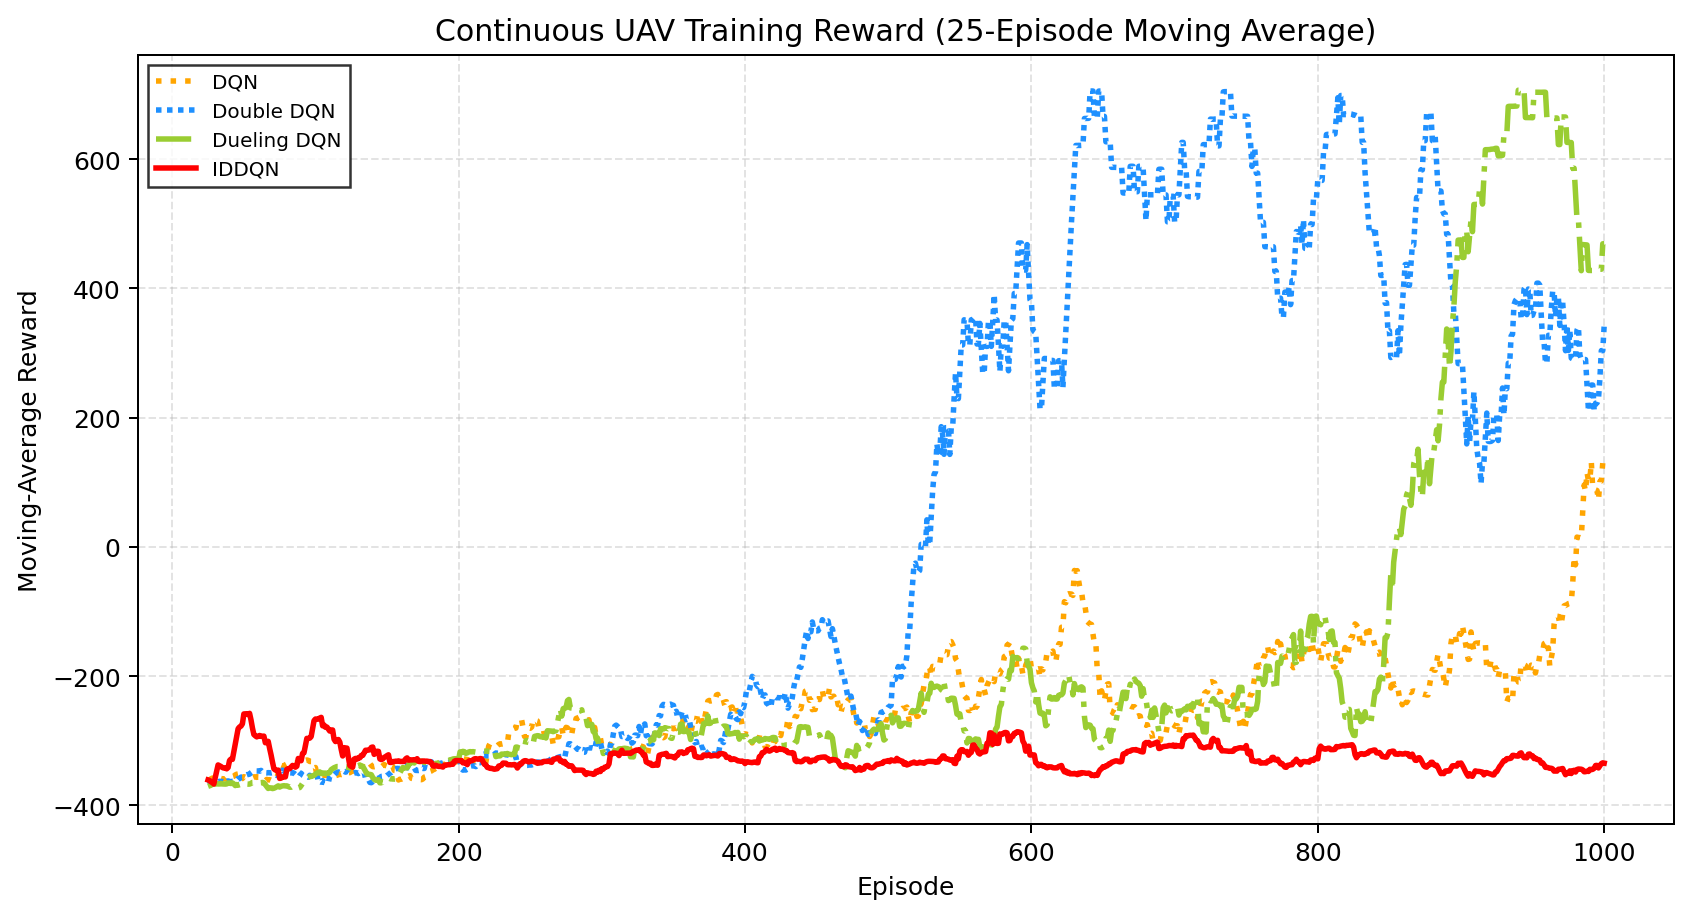

In [37]:
# Episodes vs reward plots.
def moving_average(values, window=25):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

reward_rows = []
for algorithm in ALGORITHMS:
    rewards = histories[algorithm]["reward"]
    for episode, reward in enumerate(rewards, start=1):
        reward_rows.append({"algorithm": algorithm, "episode": episode, "reward": reward})
reward_history_df = pd.DataFrame(reward_rows)
reward_history_df.to_csv(REWARD_CSV, index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.2), dpi=180)
window = 25
for algorithm in ALGORITHMS:
    rewards = np.asarray(histories[algorithm]["reward"], dtype=float)
    smooth = moving_average(rewards, window)
    x = np.arange(window, len(rewards) + 1) if len(rewards) >= window else np.arange(1, len(rewards) + 1)
    ax.plot(x, smooth, label=algorithm, color=STYLE[algorithm]["color"], linestyle=STYLE[algorithm]["linestyle"], linewidth=2.2)
ax.set_title(f"Continuous UAV Training Reward ({window}-Episode Moving Average)")
ax.set_xlabel("Episode")
ax.set_ylabel("Moving-Average Reward")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(frameon=True, fancybox=False, edgecolor="black", fontsize=8)
fig.tight_layout()
fig.savefig(REWARD_PLOT, dpi=300, bbox_inches="tight")
plt.show()